In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# EXPERIMENTO 2: TRANSFERENCIA LSTM ENTRE PLANTAS SOLARES
# Pre-entrenamiento sobre 5 plantas fuente → Zero-shot + Fine-tuning en TALASOL
# ============================================================================
#
# Estrategia de transferencia:
# - Mismo LSTMForecaster (n_features fijo) para todas las plantas.
# - Pre-entrenamiento multi-planta con ConcatDataset.
# - Transferencia via state_dict: zero-shot y fine-tuning progresivo.
# - Layer freezing: congela encoder LSTM, adapta attention + decoder.
#
# En Google Colab: monta Drive y ejecuta os.chdir() ANTES de esta celda.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')

import sys
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from pathlib import Path

# Módulos del proyecto
from lstm_model import LSTMForecaster, LSTMTrainer
from data_loaders import SolarSequenceDataset
from evaluation import ForecastEvaluator

# Módulos del experimento 2 — LSTM
from ex2_transfer.ex2_lstm_config import (
    PLANTAS_SOURCE, PLANTA_TARGET,
    SMOKE_TEST, SMOKE_MAX_ROWS,
    DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR,
    DEVICE, SEQ_LENGTH,
    FEATURE_COLS, FUTURE_FEATURE_COLS, LAG_STEPS, N_FEATURES_TOTAL,
    MODEL_CFG, FINETUNE_CFG, FINETUNE_SIZES,
)
from ex2_transfer.lstm_transfer import (
    load_plant_split,
    build_source_loaders,
    build_target_loaders,
    evaluate,
    save_results_row,
    LSTMTransferTrainer,
)
from ex1_compare.visualization import (
    plot_diagnostic, plot_timeseries, plot_learning_curves,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 80)
print('EXPERIMENTO 2: TRANSFERENCIA LSTM')
print(f'Plantas fuente : {PLANTAS_SOURCE}')
print(f'Planta destino : {PLANTA_TARGET}')
print(f'Device         : {DEVICE}')
print(f'Smoke test     : {SMOKE_TEST}')
print(f'SEQ_LENGTH     : {SEQ_LENGTH}h')
print(f'N_FEATURES     : {N_FEATURES_TOTAL}  ({len(FEATURE_COLS)} base + {len(LAG_STEPS)} lags)')
print(f'MODEL_CFG      : {MODEL_CFG}')
print(f'FINETUNE_CFG   : {FINETUNE_CFG}')
print(f'FINETUNE_SIZES : {list(FINETUNE_SIZES.keys())}')
print('=' * 80)

[ex2_lstm] Entorno: Google Colab | Device: cuda (Tesla T4)
[ex1] Entorno: Google Colab | Device: cuda (Tesla T4)
EXPERIMENTO 2: TRANSFERENCIA LSTM
Plantas fuente : ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA']
Planta destino : TALASOL
Device         : cuda
Smoke test     : False
SEQ_LENGTH     : 48h
N_FEATURES     : 17  (12 base + 5 lags)
MODEL_CFG      : {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.4, 'noise_std': 0.02, 'batch_size': 64, 'max_epochs': 50, 'patience': 10, 'lr': 0.001, 'loss_alpha': 0.7}
FINETUNE_CFG   : {'max_epochs': 30, 'patience': 5, 'lr_factor': 0.1}
FINETUNE_SIZES : ['zero_shot', '1_semana', '1_mes', '3_meses']


In [3]:
# ============================================================================
# KEEP-ALIVE COLAB — Evita desconexión por inactividad durante entrenamientos largos
# Ejecutar esta celda UNA VEZ antes del entrenamiento (solo tiene efecto en Colab)
# ============================================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from IPython.display import display, Javascript
    display(Javascript("""
    function ClickConnect(){
        console.log("Keep-alive: click en 'Conectar'");
        document.querySelector("colab-toolbar-button#connect")?.click();
    }
    var interval = setInterval(ClickConnect, 60000);
    console.log("Keep-alive iniciado (interval id=" + interval + ")");
    """))
    print("✓ Keep-alive activado (click automático cada 60 s)")
else:
    print("Entorno local — keep-alive no necesario")

<IPython.core.display.Javascript object>

✓ Keep-alive activado (click automático cada 60 s)


In [4]:
# ============================================================================
# 1. CARGA DE DATOS
# ============================================================================

print('[1/7] Cargando datos...')

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'  Train: {len(df_train):,} registros')
print(f'  Val:   {len(df_val):,} registros')
print(f'  Test:  {len(df_test):,} registros')
print(f'  Plantas disponibles: {sorted(df_train["planta_nombre"].unique())}')

# Verificar que todas las plantas están presentes
todas = PLANTAS_SOURCE + [PLANTA_TARGET]
plantas_disponibles = set(df_train['planta_nombre'].unique())
for p in todas:
    if p not in plantas_disponibles:
        raise ValueError(f'Planta {p!r} no encontrada en train.csv')

# Verificar features requeridas
for col in FEATURE_COLS + FUTURE_FEATURE_COLS:
    if col not in df_train.columns:
        raise ValueError(f'Columna {col!r} no encontrada en train.csv')

print(f'\nShapes por planta (train):')
for p in todas:
    df_p = load_plant_split(df_train, p, SMOKE_TEST, SMOKE_MAX_ROWS)
    print(f'  {p}: {len(df_p):,} filas')

print(f'\nFeatures LSTM:')
print(f'  Históricas  ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'  Futuras     ({len(FUTURE_FEATURE_COLS)}): {FUTURE_FEATURE_COLS}')
print(f'  Lag steps   ({len(LAG_STEPS)}): {LAG_STEPS}')
print(f'  Total features por timestep: {N_FEATURES_TOTAL}')
print('\n[1/7] OK')

[1/7] Cargando datos...
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros
  Plantas disponibles: ['FVARENA', 'NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']

Shapes por planta (train):
  UPGARNACHA: 6,050 filas
  FVARENA: 8,978 filas
  NBALBOA: 8,955 filas
  RODRI: 8,978 filas
  UFMULA: 8,978 filas
  TALASOL: 8,978 filas

Features LSTM:
  Históricas  (12): ['shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover', 'temperature_2m', 'elevacion_solar', 'azimut_solar', 'hora', 'dia_semana', 'mes', 'dia_año', 'es_dia']
  Futuras     (7): ['shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover', 'elevacion_solar', 'hora', 'es_dia']
  Lag steps   (5): [1, 2, 3, 24, 48]
  Total features por timestep: 17

[1/7] OK


In [6]:
# ============================================================================
# 2. PRE-ENTRENAMIENTO MULTI-PLANTA (plantas fuente)
# ============================================================================
import time

print('[2/7] Pre-entrenamiento LSTM multi-planta...')
print('=' * 80)

ckpt_pretrained = CHECKPOINTS_DIR / 'pretrained.pt'

# ── RESUME: si ya existe el checkpoint, cargar y saltar pretraining ───────────
_resumed = False
if ckpt_pretrained.exists():
    try:
        print(f'  ✓ Checkpoint encontrado — skip pretraining')
        ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
        model = LSTMForecaster(
            n_features        = N_FEATURES_TOTAL,
            n_future_features = len(FUTURE_FEATURE_COLS),
            hidden_size       = MODEL_CFG['hidden_size'],
            num_layers        = MODEL_CFG['num_layers'],
            dropout           = MODEL_CFG['dropout'],
            noise_std         = MODEL_CFG['noise_std'],
        )
        model.load_state_dict(ckpt['model_state_dict'])
        model.to(DEVICE)
        transfer_trainer    = LSTMTransferTrainer(model, DEVICE)
        transfer_trainer._pretrain_state = ckpt['model_state_dict']
        pretrain_hist   = {'train': [], 'val': []}
        pretrain_time_s = 0.0
        print(f'  Modelo cargado: {ckpt_pretrained}')
        print('[2/7] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        ckpt_pretrained.unlink(missing_ok=True)
if not _resumed:
    # DataLoaders multi-planta
    print('\nConstruyendo DataLoaders de plantas fuente:')
    train_loader, val_loader, scalers_source = build_source_loaders(
        plantas_source      = PLANTAS_SOURCE,
        df_train            = df_train,
        df_val              = df_val,
        feature_cols        = FEATURE_COLS,
        future_feature_cols = FUTURE_FEATURE_COLS,
        lag_steps           = LAG_STEPS,
        seq_length          = SEQ_LENGTH,
        batch_size          = MODEL_CFG['batch_size'],
        smoke_test          = SMOKE_TEST,
        max_rows            = SMOKE_MAX_ROWS,
    )

    # Crear modelo
    model = LSTMForecaster(
        n_features        = N_FEATURES_TOTAL,
        n_future_features = len(FUTURE_FEATURE_COLS),
        hidden_size       = MODEL_CFG['hidden_size'],
        num_layers        = MODEL_CFG['num_layers'],
        dropout           = MODEL_CFG['dropout'],
        noise_std         = MODEL_CFG['noise_std'],
    )

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nModelo LSTM: {n_params:,} parámetros')
    print(f'  hidden_size={MODEL_CFG["hidden_size"]}  num_layers={MODEL_CFG["num_layers"]}  '
          f'n_features={N_FEATURES_TOTAL}  n_future={len(FUTURE_FEATURE_COLS)}')

    # Pre-entrenamiento
    transfer_trainer = LSTMTransferTrainer(model, DEVICE)
    print(f'\nPre-entrenando {MODEL_CFG["max_epochs"]} epochs '
          f'(patience={MODEL_CFG["patience"]})...')
    t0 = time.time()
    pretrain_hist = transfer_trainer.pretrain(train_loader, val_loader, MODEL_CFG)
    pretrain_time_s = time.time() - t0
    print(f'  Tiempo pretraining: {pretrain_time_s/60:.1f} min ({pretrain_time_s:.0f} s)')

    # Guardar checkpoint
    torch.save({
        'model_state_dict':    transfer_trainer._pretrain_state,
        'model_cfg':           MODEL_CFG,
        'plantas_source':      PLANTAS_SOURCE,
        'seq_length':          SEQ_LENGTH,
        'feature_cols':        FEATURE_COLS,
        'future_feature_cols': FUTURE_FEATURE_COLS,
        'lag_steps':           LAG_STEPS,
    }, ckpt_pretrained)
    print(f'  ✓ Checkpoint guardado: {ckpt_pretrained}')

    # Curvas de aprendizaje del pretraining
    plot_learning_curves(
        [pretrain_hist], PLANTA_TARGET, 'lstm-pretrain',
        save_dir=RESULTS_DIR / 'figures'
    )
    print('[2/7] OK')

[2/7] Pre-entrenamiento LSTM multi-planta...
  ✓ Checkpoint encontrado — skip pretraining
  Modelo cargado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex2_transfer/lstm/pretrained.pt
[2/7] OK (desde checkpoint)


[3/7] Zero-shot en TALASOL...
  TALASOL: zero-shot (sin fine-tuning)
  val=945  test=1,439  scaler_mean=227.5
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=zero_shot  MAE=52.144901275634766  RMSE=116.1261978149414  R2=0.6438999772071838

Zero-shot → MAE=52.14  RMSE=116.13  MAPE=53.93%  R2=0.6439
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_diagnostic.png


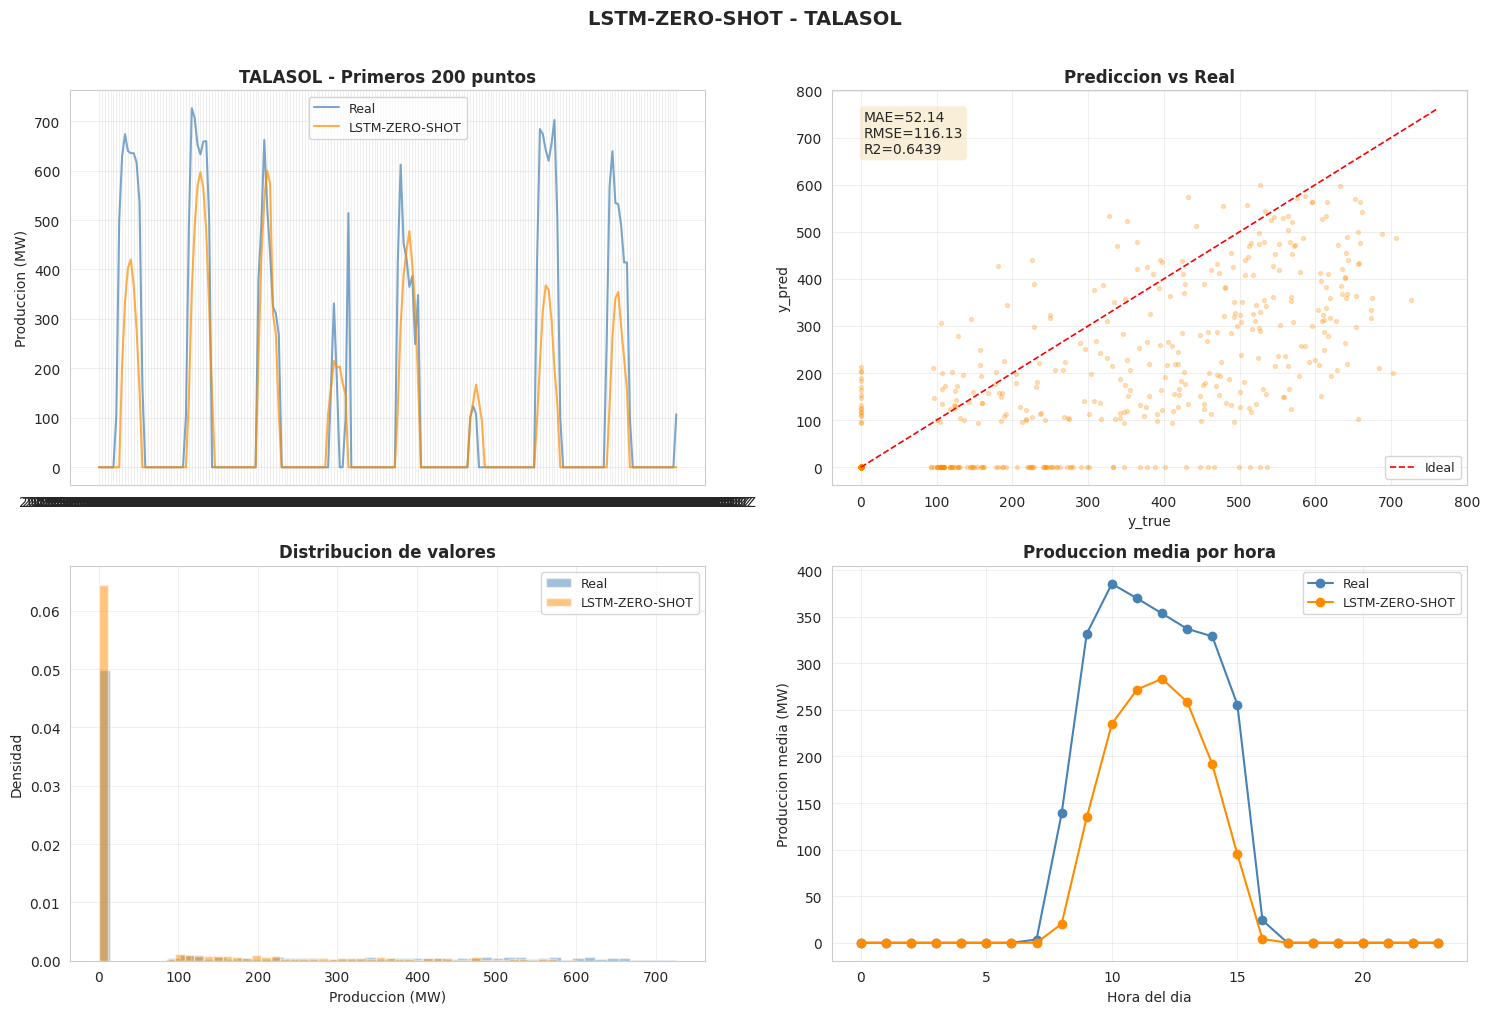

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_timeseries.png


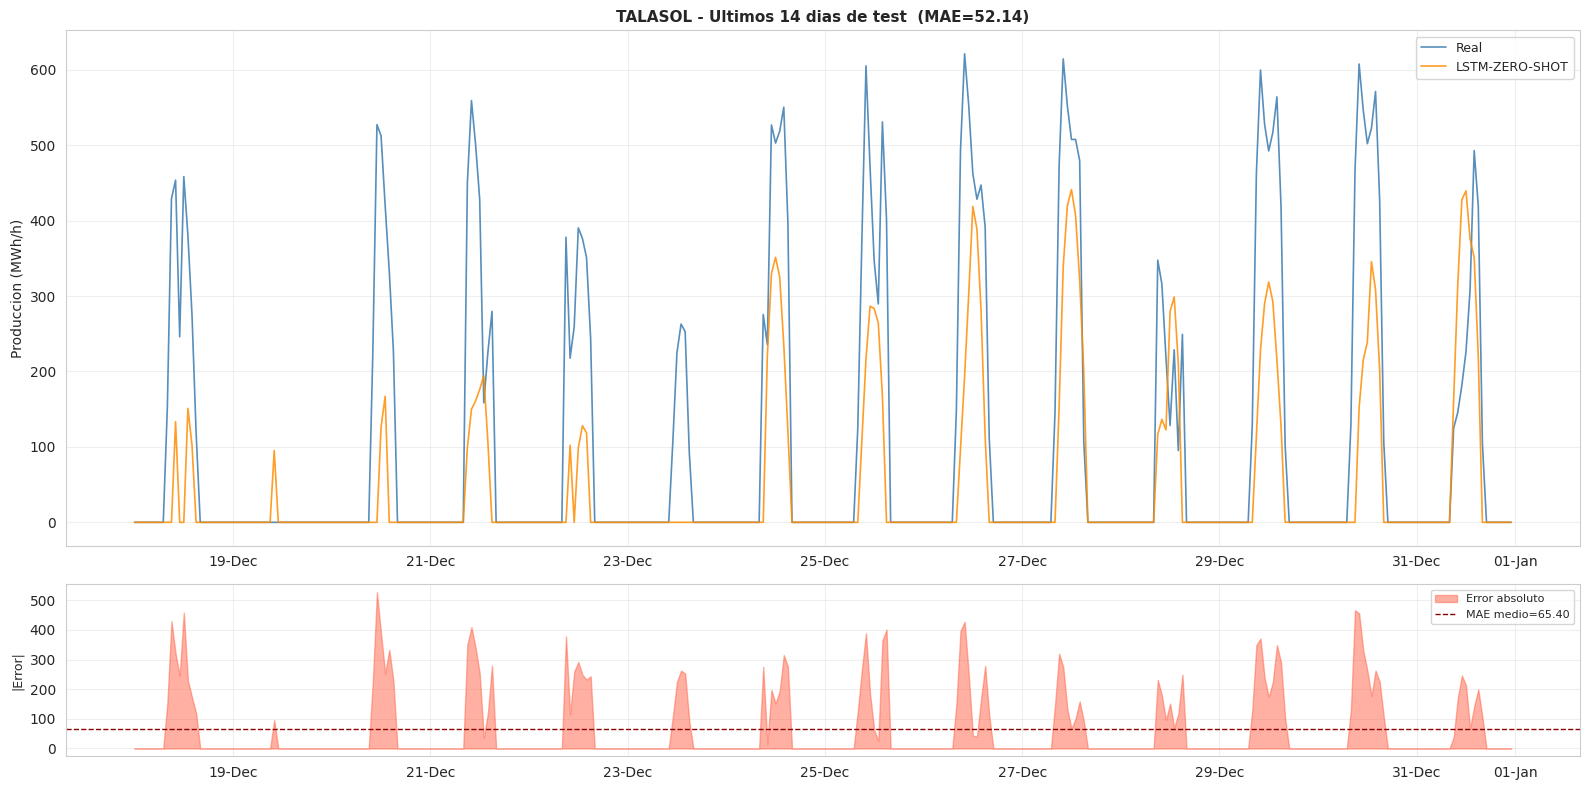

[3/7] OK


In [7]:
# ============================================================================
# 3. EVALUACIÓN ZERO-SHOT EN TALASOL
# ============================================================================

print('[3/7] Zero-shot en TALASOL...')
print('=' * 80)

preds_zs_csv = CHECKPOINTS_DIR / 'preds_zero_shot.csv'

# ── RESUME ────────────────────────────────────────────────────────────────────
_resumed = False
if preds_zs_csv.exists():
    try:
        print(f'  ✓ Predicciones zero-shot encontradas — skip inferencia')
        df_pred_zs = pd.read_csv(preds_zs_csv)
        if 'timestamp' in df_pred_zs.columns:
            df_pred_zs['timestamp'] = pd.to_datetime(df_pred_zs['timestamp'])
        print('[3/7] OK (desde CSV)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        preds_zs_csv.unlink(missing_ok=True)
if not _resumed:
    _, val_loader_tgt, test_loader_tgt, test_ds_tgt, scaler_y_tgt = build_target_loaders(
        planta_target       = PLANTA_TARGET,
        df_train            = df_train,
        df_val              = df_val,
        df_test             = df_test,
        feature_cols        = FEATURE_COLS,
        future_feature_cols = FUTURE_FEATURE_COLS,
        lag_steps           = LAG_STEPS,
        seq_length          = SEQ_LENGTH,
        batch_size          = MODEL_CFG['batch_size'],
        n_finetune_hours    = 0,
        smoke_test          = SMOKE_TEST,
        max_rows            = SMOKE_MAX_ROWS,
    )

    ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(DEVICE)
    model.eval()

    metrics_zs = evaluate(model, test_ds_tgt, DEVICE)
    metrics_zs['training_time_s'] = 0.0
    save_results_row(RESULTS_DIR, 'zero_shot', metrics_zs, n_ft_hours=0)

    print(f"\nZero-shot → MAE={metrics_zs['MAE']:.2f}  "
          f"RMSE={metrics_zs['RMSE']:.2f}  "
          f"MAPE={metrics_zs['MAPE']:.2f}%  "
          f"R2={metrics_zs['R2']:.4f}")

    df_pred_zs = test_ds_tgt.get_full_predictions(model, device=DEVICE)
    df_pred_zs.to_csv(preds_zs_csv, index=False)

    plot_diagnostic(df_pred_zs, PLANTA_TARGET, 'lstm-zero-shot',
                    save_dir=RESULTS_DIR / 'figures')
    plot_timeseries(df_pred_zs, PLANTA_TARGET, 'lstm-zero-shot',
                    save_dir=RESULTS_DIR / 'figures', days=14)
    print('[3/7] OK')

In [8]:
# ============================================================================
# 4. FINE-TUNING PROGRESIVO EN TALASOL
# ============================================================================

print('[4/7] Fine-tuning progresivo...')
print('=' * 80)

ft_scenarios = {k: v for k, v in FINETUNE_SIZES.items() if v > 0}

ft_histories = {}
ft_preds     = {}
ft_times     = {}

for scenario_name, n_hours in ft_scenarios.items():
    print(f'\n--- Fine-tuning: {scenario_name} ({n_hours} horas) ---')

    # ── RESUME: si ya existen predicciones guardadas, cargar y saltar ─────────
    preds_csv    = CHECKPOINTS_DIR / f'preds_ft_{scenario_name}.csv'
    ckpt_ft_path = CHECKPOINTS_DIR / f'finetuned_{scenario_name}.pt'
    if preds_csv.exists():
        print(f'  ✓ Checkpoint encontrado — skip ft_{scenario_name}')
        try:
            df_tmp = pd.read_csv(preds_csv)
            if 'timestamp' in df_tmp.columns:
                df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])
            ft_preds[scenario_name]     = df_tmp
            ft_times[scenario_name]     = 0.0
            ft_histories[scenario_name] = {'train': [], 'val': []}
            continue
        except Exception as _e:
            print(f'  ⚠ CSV corrupto — re-entrenando: {_e}')
            preds_csv.unlink(missing_ok=True)

    ft_loader, val_loader_ft, _, test_ds_ft, scaler_y_ft = build_target_loaders(
        planta_target       = PLANTA_TARGET,
        df_train            = df_train,
        df_val              = df_val,
        df_test             = df_test,
        feature_cols        = FEATURE_COLS,
        future_feature_cols = FUTURE_FEATURE_COLS,
        lag_steps           = LAG_STEPS,
        seq_length          = SEQ_LENGTH,
        batch_size          = MODEL_CFG['batch_size'],
        n_finetune_hours    = n_hours,
        smoke_test          = SMOKE_TEST,
        max_rows            = SMOKE_MAX_ROWS,
    )

    if ft_loader is None:
        print(f'  ⚠ Datos insuficientes — saltando {scenario_name}')
        continue

    # Modelo nuevo desde pesos del pretraining
    model_ft = LSTMForecaster(
        n_features        = N_FEATURES_TOTAL,
        n_future_features = len(FUTURE_FEATURE_COLS),
        hidden_size       = MODEL_CFG['hidden_size'],
        num_layers        = MODEL_CFG['num_layers'],
        dropout           = MODEL_CFG['dropout'],
        noise_std         = MODEL_CFG['noise_std'],
    )
    trainer_ft = LSTMTransferTrainer(model_ft, DEVICE)
    ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
    model_ft.load_state_dict(ckpt['model_state_dict'])
    trainer_ft._pretrain_state = ckpt['model_state_dict']

    ft_cfg = {**FINETUNE_CFG, 'lr': MODEL_CFG['lr'],
              'loss_alpha': MODEL_CFG['loss_alpha']}
    t0 = time.time()
    ft_hist = trainer_ft.finetune(ft_loader, val_loader_ft, ft_cfg, freeze_lstm=False)
    ft_times[scenario_name] = time.time() - t0
    ft_histories[scenario_name] = ft_hist
    print(f'  Tiempo FT: {ft_times[scenario_name]/60:.1f} min ({ft_times[scenario_name]:.0f} s)')

    # Evaluación
    metrics_ft = evaluate(model_ft, test_ds_ft, DEVICE)
    metrics_ft['training_time_s'] = ft_times[scenario_name]
    save_results_row(RESULTS_DIR, f'ft_{scenario_name}', metrics_ft, n_ft_hours=n_hours)

    print(f"  → MAE={metrics_ft['MAE']:.2f}  RMSE={metrics_ft['RMSE']:.2f}  "
          f"MAPE={metrics_ft['MAPE']:.2f}%  R2={metrics_ft['R2']:.4f}")

    # Guardar checkpoint + predicciones
    torch.save({
        'model_state_dict': trainer_ft.trainer.best_state,
        'scenario':         scenario_name,
        'n_ft_hours':       n_hours,
    }, ckpt_ft_path)

    df_pred_ft = test_ds_ft.get_full_predictions(model_ft, device=DEVICE)
    df_pred_ft.to_csv(preds_csv, index=False)
    ft_preds[scenario_name] = df_pred_ft
    print(f'  ✓ Checkpoint guardado → {ckpt_ft_path.name}')

print('\n[4/7] OK')

[4/7] Fine-tuning progresivo...

--- Fine-tuning: 1_semana (168 horas) ---
  TALASOL fine-tune: 149 muestras (216 filas de train, 168h solicitadas, batch_size=64)
  val=945  test=1,439  scaler_mean=227.5


Training:  17%|█▋        | 5/30 [00:00<00:01, 13.83it/s, best=0.2158, lr=1.0e-04, train=0.0449, val=0.2179]



Early stopping época 6

✓ Completado  |  best val_loss: 0.215837
  Tiempo FT: 0.0 min (0 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=ft_1_semana  MAE=53.094398498535156  RMSE=118.23970031738281  R2=0.6309000253677368
  → MAE=53.09  RMSE=118.24  MAPE=54.62%  R2=0.6309
  ✓ Checkpoint guardado → finetuned_1_semana.pt

--- Fine-tuning: 1_mes (720 horas) ---
  TALASOL fine-tune: 701 muestras (768 filas de train, 720h solicitadas, batch_size=64)
  val=945  test=1,439  scaler_mean=227.5


Training:  67%|██████▋   | 20/30 [00:02<00:01,  8.58it/s, best=0.2123, lr=1.0e-04, train=0.0341, val=0.2148]



Early stopping época 21

✓ Completado  |  best val_loss: 0.212317
  Tiempo FT: 0.0 min (2 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=ft_1_mes  MAE=46.8656005859375  RMSE=103.27120208740234  R2=0.7184000015258789
  → MAE=46.87  RMSE=103.27  MAPE=47.29%  R2=0.7184
  ✓ Checkpoint guardado → finetuned_1_mes.pt

--- Fine-tuning: 3_meses (2160 horas) ---
  TALASOL fine-tune: 2,141 muestras (2208 filas de train, 2160h solicitadas, batch_size=64)
  val=945  test=1,439  scaler_mean=227.5


Training:  20%|██        | 6/30 [00:01<00:06,  3.47it/s, best=0.2238, lr=1.0e-04, train=0.0303, val=0.2313]



Early stopping época 7

✓ Completado  |  best val_loss: 0.223754
  Tiempo FT: 0.0 min (2 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=ft_3_meses  MAE=56.39899826049805  RMSE=123.98639678955078  R2=0.5940999984741211
  → MAE=56.40  RMSE=123.99  MAPE=57.09%  R2=0.5941
  ✓ Checkpoint guardado → finetuned_3_meses.pt

[4/7] OK


In [9]:
# ============================================================================
# 4b. FINE-TUNING CON LAYER FREEZING (encoder LSTM congelado)
# ============================================================================

print('[4b/7] Fine-tuning con layer freezing (encoder LSTM congelado)...')
print('=' * 80)
print('Congelado: model.lstm (encoder recurrente)')
print('Entrenable: model.attention + model.fc1 + model.fc2')

ft_frozen_histories = {}
ft_frozen_preds     = {}
ft_frozen_times     = {}

ft_cfg_frozen = {**FINETUNE_CFG, 'lr': MODEL_CFG['lr'],
                 'lr_factor': 1.0, 'loss_alpha': MODEL_CFG['loss_alpha']}

for scenario_name, n_hours in ft_scenarios.items():
    print(f'\n--- Fine-tuning frozen: {scenario_name} ({n_hours} horas) ---')

    # ── RESUME ────────────────────────────────────────────────────────────────
    preds_csv_frz = CHECKPOINTS_DIR / f'preds_ft_frozen_{scenario_name}.csv'
    ckpt_frz_path = CHECKPOINTS_DIR / f'finetuned_frozen_{scenario_name}.pt'
    if preds_csv_frz.exists():
        print(f'  ✓ Checkpoint encontrado — skip ft_frozen_{scenario_name}')
        try:
            df_tmp = pd.read_csv(preds_csv_frz)
            if 'timestamp' in df_tmp.columns:
                df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])
            ft_frozen_preds[scenario_name]     = df_tmp
            ft_frozen_times[scenario_name]     = 0.0
            ft_frozen_histories[scenario_name] = {'train': [], 'val': []}
            continue
        except Exception as _e:
            print(f'  ⚠ CSV corrupto — re-entrenando: {_e}')
            preds_csv_frz.unlink(missing_ok=True)

    ft_loader_frz, val_loader_frz, _, test_ds_frz, scaler_y_frz = build_target_loaders(
        planta_target       = PLANTA_TARGET,
        df_train            = df_train,
        df_val              = df_val,
        df_test             = df_test,
        feature_cols        = FEATURE_COLS,
        future_feature_cols = FUTURE_FEATURE_COLS,
        lag_steps           = LAG_STEPS,
        seq_length          = SEQ_LENGTH,
        batch_size          = MODEL_CFG['batch_size'],
        n_finetune_hours    = n_hours,
        smoke_test          = SMOKE_TEST,
        max_rows            = SMOKE_MAX_ROWS,
    )

    if ft_loader_frz is None:
        print(f'  ⚠ Datos insuficientes para {scenario_name} — saltando')
        continue

    model_frz = LSTMForecaster(
        n_features        = N_FEATURES_TOTAL,
        n_future_features = len(FUTURE_FEATURE_COLS),
        hidden_size       = MODEL_CFG['hidden_size'],
        num_layers        = MODEL_CFG['num_layers'],
        dropout           = MODEL_CFG['dropout'],
        noise_std         = MODEL_CFG['noise_std'],
    )
    trainer_frz = LSTMTransferTrainer(model_frz, DEVICE)
    ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
    model_frz.load_state_dict(ckpt['model_state_dict'])
    trainer_frz._pretrain_state = ckpt['model_state_dict']

    t0 = time.time()
    frz_hist = trainer_frz.finetune(
        ft_loader_frz, val_loader_frz, ft_cfg_frozen,
        freeze_lstm=True,
    )
    ft_frozen_times[scenario_name] = time.time() - t0
    ft_frozen_histories[scenario_name] = frz_hist
    print(f'  Tiempo FT frozen: {ft_frozen_times[scenario_name]/60:.1f} min '
          f'({ft_frozen_times[scenario_name]:.0f} s)')

    metrics_frz = evaluate(model_frz, test_ds_frz, DEVICE)
    metrics_frz['training_time_s'] = ft_frozen_times[scenario_name]
    save_results_row(RESULTS_DIR, f'ft_frozen_{scenario_name}',
                     metrics_frz, n_ft_hours=n_hours)

    print(f"  → MAE={metrics_frz['MAE']:.2f}  RMSE={metrics_frz['RMSE']:.2f}  "
          f"MAPE={metrics_frz['MAPE']:.2f}%  R2={metrics_frz['R2']:.4f}")

    torch.save({
        'model_state_dict': trainer_frz.trainer.best_state,
        'scenario':         f'ft_frozen_{scenario_name}',
        'n_ft_hours':       n_hours,
        'frozen':           True,
    }, ckpt_frz_path)

    df_pred_frz = test_ds_frz.get_full_predictions(model_frz, device=DEVICE)
    df_pred_frz.to_csv(preds_csv_frz, index=False)
    ft_frozen_preds[scenario_name] = df_pred_frz
    print(f'  ✓ Checkpoint guardado → {ckpt_frz_path.name}')

print('\n[4b/7] OK')

[4b/7] Fine-tuning con layer freezing (encoder LSTM congelado)...
Congelado: model.lstm (encoder recurrente)
Entrenable: model.attention + model.fc1 + model.fc2

--- Fine-tuning frozen: 1_semana (168 horas) ---
  TALASOL fine-tune: 149 muestras (216 filas de train, 168h solicitadas, batch_size=64)
  val=945  test=1,439  scaler_mean=227.5
  [fine-tune] Congelado: lstm | entrenables: 690/15,666


Training:  17%|█▋        | 5/30 [00:00<00:01, 14.14it/s, best=0.2192, lr=1.0e-03, train=0.0355, val=0.2589]



Early stopping época 6

✓ Completado  |  best val_loss: 0.219166
  Tiempo FT frozen: 0.0 min (0 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=ft_frozen_1_semana  MAE=56.246700286865234  RMSE=122.22969818115234  R2=0.6054999828338623
  → MAE=56.25  RMSE=122.23  MAPE=55.75%  R2=0.6055
  ✓ Checkpoint guardado → finetuned_frozen_1_semana.pt

--- Fine-tuning frozen: 1_mes (720 horas) ---
  TALASOL fine-tune: 701 muestras (768 filas de train, 720h solicitadas, batch_size=64)
  val=945  test=1,439  scaler_mean=227.5
  [fine-tune] Congelado: lstm | entrenables: 690/15,666


Training:  17%|█▋        | 5/30 [00:00<00:02,  8.60it/s, best=0.2383, lr=1.0e-03, train=0.0345, val=0.3208]



Early stopping época 6

✓ Completado  |  best val_loss: 0.238321
  Tiempo FT frozen: 0.0 min (1 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=ft_frozen_1_mes  MAE=62.09339904785156  RMSE=133.59339904785156  R2=0.5288000106811523
  → MAE=62.09  RMSE=133.59  MAPE=60.77%  R2=0.5288
  ✓ Checkpoint guardado → finetuned_frozen_1_mes.pt

--- Fine-tuning frozen: 3_meses (2160 horas) ---
  TALASOL fine-tune: 2,141 muestras (2208 filas de train, 2160h solicitadas, batch_size=64)
  val=945  test=1,439  scaler_mean=227.5
  [fine-tune] Congelado: lstm | entrenables: 690/15,666


Training:  17%|█▋        | 5/30 [00:01<00:05,  4.18it/s, best=0.3036, lr=1.0e-03, train=0.0297, val=0.5413]



Early stopping época 6

✓ Completado  |  best val_loss: 0.303588
  Tiempo FT frozen: 0.0 min (1 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=ft_frozen_3_meses  MAE=76.52989959716797  RMSE=160.5323944091797  R2=0.319599986076355
  → MAE=76.53  RMSE=160.53  MAPE=74.82%  R2=0.3196
  ✓ Checkpoint guardado → finetuned_frozen_3_meses.pt

[4b/7] OK


In [10]:
# ============================================================================
# 5. BASELINE: LSTM ENTRENADO DESDE CERO EN TALASOL
# ============================================================================

print('[5/7] Baseline (LSTM entrenado desde cero en TALASOL)...')
print('=' * 80)

preds_bl_csv = CHECKPOINTS_DIR / 'preds_baseline.csv'
ckpt_bl_path = CHECKPOINTS_DIR / 'baseline_scratch.pt'

# ── RESUME ────────────────────────────────────────────────────────────────────
_resumed = False
if preds_bl_csv.exists():
    try:
        print(f'  ✓ Checkpoint baseline encontrado — skip')
        df_pred_bl = pd.read_csv(preds_bl_csv)
        if 'timestamp' in df_pred_bl.columns:
            df_pred_bl['timestamp'] = pd.to_datetime(df_pred_bl['timestamp'])
        baseline_hist   = {'train': [], 'val': []}
        baseline_time_s = 0.0
        print('[5/7] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        preds_bl_csv.unlink(missing_ok=True)
if not _resumed:
    ft_loader_bl, val_loader_bl, _, test_ds_bl, scaler_y_bl = build_target_loaders(
        planta_target       = PLANTA_TARGET,
        df_train            = df_train,
        df_val              = df_val,
        df_test             = df_test,
        feature_cols        = FEATURE_COLS,
        future_feature_cols = FUTURE_FEATURE_COLS,
        lag_steps           = LAG_STEPS,
        seq_length          = SEQ_LENGTH,
        batch_size          = MODEL_CFG['batch_size'],
        n_finetune_hours    = None,
        smoke_test          = SMOKE_TEST,
        max_rows            = SMOKE_MAX_ROWS,
    )

    model_bl = LSTMForecaster(
        n_features        = N_FEATURES_TOTAL,
        n_future_features = len(FUTURE_FEATURE_COLS),
        hidden_size       = MODEL_CFG['hidden_size'],
        num_layers        = MODEL_CFG['num_layers'],
        dropout           = MODEL_CFG['dropout'],
        noise_std         = MODEL_CFG['noise_std'],
    )
    trainer_bl = LSTMTransferTrainer(model_bl, DEVICE)

    print(f'\nEntrenando desde cero: {MODEL_CFG["max_epochs"]} epochs...')
    t0 = time.time()
    baseline_hist = trainer_bl.pretrain(ft_loader_bl, val_loader_bl, MODEL_CFG)
    baseline_time_s = time.time() - t0
    print(f'  Tiempo baseline: {baseline_time_s/60:.1f} min ({baseline_time_s:.0f} s)')

    metrics_bl = evaluate(model_bl, test_ds_bl, DEVICE)
    metrics_bl['training_time_s'] = baseline_time_s
    save_results_row(RESULTS_DIR, 'baseline', metrics_bl, n_ft_hours=0)

    print(f"\nBaseline → MAE={metrics_bl['MAE']:.2f}  "
          f"RMSE={metrics_bl['RMSE']:.2f}  "
          f"MAPE={metrics_bl['MAPE']:.2f}%  "
          f"R2={metrics_bl['R2']:.4f}")

    torch.save({'model_state_dict': trainer_bl._pretrain_state,
                'scenario': 'baseline'}, ckpt_bl_path)

    df_pred_bl = test_ds_bl.get_full_predictions(model_bl, device=DEVICE)
    df_pred_bl.to_csv(preds_bl_csv, index=False)
    print(f'  ✓ Checkpoint guardado → {ckpt_bl_path.name}')
    print('[5/7] OK')

[5/7] Baseline (LSTM entrenado desde cero en TALASOL)...
  TALASOL baseline: 8,405 muestras (todo el train)
  val=945  test=1,439  scaler_mean=227.5

Entrenando desde cero: 50 epochs...


Training:  82%|████████▏ | 41/50 [00:34<00:07,  1.21it/s, best=0.2063, lr=1.0e-03, train=0.0640, val=0.2529]



Early stopping época 42

✓ Completado  |  best val_loss: 0.206319
  Tiempo baseline: 0.6 min (34 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/metrics.csv  | scenario=baseline  MAE=84.18440246582031  RMSE=175.40989685058594  R2=0.1876000016927719

Baseline → MAE=84.18  RMSE=175.41  MAPE=82.05%  R2=0.1876
  ✓ Checkpoint guardado → baseline_scratch.pt
[5/7] OK


In [11]:
# ============================================================================
# 6. TABLA RESUMEN
# ============================================================================

print('[6/7] Tabla resumen...')

df_results = pd.read_csv(RESULTS_DIR / 'metrics.csv')

# Última ejecución de cada escenario
df_latest = (
    df_results
    .sort_values('timestamp')
    .groupby('scenario', as_index=False)
    .last()
)

# Orden lógico
scenario_order = [
    'zero_shot',
    'ft_1_semana',        'ft_frozen_1_semana',
    'ft_1_mes',           'ft_frozen_1_mes',
    'ft_3_meses',         'ft_frozen_3_meses',
    'baseline',
]
df_latest['_order'] = df_latest['scenario'].map(
    {s: i for i, s in enumerate(scenario_order)}
).fillna(99)
df_latest = df_latest.sort_values('_order').drop(columns='_order')

# Mejoras relativas
zs_mae = df_latest.loc[df_latest['scenario'] == 'zero_shot', 'MAE'].values
bl_mae = df_latest.loc[df_latest['scenario'] == 'baseline',  'MAE'].values

if len(zs_mae) > 0:
    df_latest['mejora_vs_zeroshot_%'] = (
        (zs_mae[0] - df_latest['MAE']) / zs_mae[0] * 100
    ).round(2)
if len(bl_mae) > 0:
    df_latest['mejora_vs_baseline_%'] = (
        (bl_mae[0] - df_latest['MAE']) / bl_mae[0] * 100
    ).round(2)

cols_show = ['scenario', 'n_ft_hours', 'MAE', 'RMSE', 'MAPE', 'R2',
             'training_time_s', 'mejora_vs_zeroshot_%', 'mejora_vs_baseline_%']
cols_show = [c for c in cols_show if c in df_latest.columns]

print('\nRESUMEN EXPERIMENTO 2 — LSTM Transfer Learning:')
print(df_latest[cols_show].to_string(index=False))
print(f'\n  Tiempo pretraining (multi-planta): {pretrain_time_s/60:.1f} min ({pretrain_time_s:.0f} s)')
print(f'  Tiempo total FT + baseline: {df_latest["training_time_s"].sum():.0f} s')

summary_path = RESULTS_DIR / 'summary.csv'
df_latest[cols_show].to_csv(summary_path, index=False)
print(f'\nTabla guardada: {summary_path}')

# ── Guardar predicciones por escenario para análisis económico (Exp 5) ────────
print('\nGuardando predicciones por escenario (Exp 5)...')
pred_rows = []

all_scenario_preds = {'zero_shot': df_pred_zs}
for k, df_p in ft_preds.items():
    all_scenario_preds[f'ft_{k}'] = df_p
for k, df_p in ft_frozen_preds.items():
    all_scenario_preds[f'ft_frozen_{k}'] = df_p
all_scenario_preds['baseline'] = df_pred_bl

for scenario, df_p in all_scenario_preds.items():
    if df_p is None or len(df_p) == 0:
        continue
    df_tmp = df_p[['timestamp', 'y_true', 'y_pred']].copy()
    df_tmp['scenario'] = scenario
    pred_rows.append(df_tmp)

if pred_rows:
    df_all_preds = pd.concat(pred_rows, ignore_index=True)
    preds_path = RESULTS_DIR / 'predictions_TALASOL.csv'
    df_all_preds.to_csv(preds_path, index=False)
    print(f'  Guardado: {preds_path}  '
          f'({len(df_all_preds)} filas, {df_all_preds["scenario"].nunique()} escenarios)')

print('[6/7] OK')


[6/7] Tabla resumen...

RESUMEN EXPERIMENTO 2 — LSTM Transfer Learning:
          scenario  n_ft_hours     MAE     RMSE    MAPE     R2  training_time_s  mejora_vs_zeroshot_%  mejora_vs_baseline_%
         zero_shot           0 52.1449 116.1262 53.9277 0.6439           0.0000                0.0000               38.0600
       ft_1_semana         168 53.0944 118.2397 54.6196 0.6309           0.4000               -1.8200               36.9300
ft_frozen_1_semana         168 56.2467 122.2297 55.7464 0.6055           0.4000               -7.8700               33.1900
          ft_1_mes         720 46.8656 103.2712 47.2931 0.7184           2.3000               10.1200               44.3300
   ft_frozen_1_mes         720 62.0934 133.5934 60.7658 0.5288           0.6000              -19.0800               26.2400
        ft_3_meses        2160 56.3990 123.9864 57.0863 0.5941           1.7000               -8.1600               33.0100
 ft_frozen_3_meses        2160 76.5299 160.5324 74.8169 0.31

[7/7] Visualización...


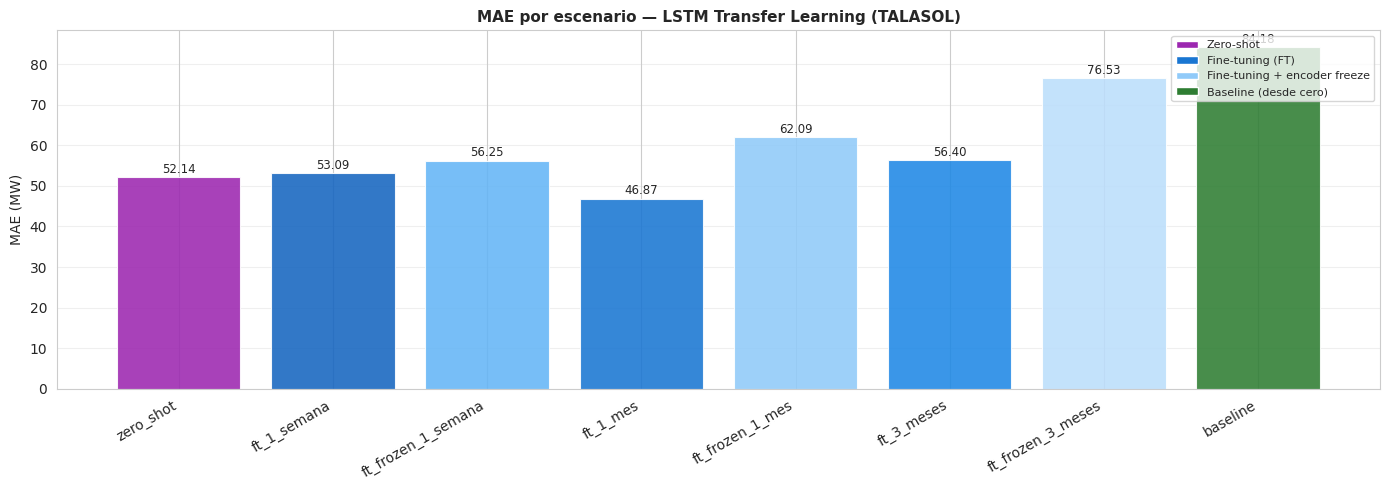

  Guardado: mae_by_scenario.png
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_timeseries.png


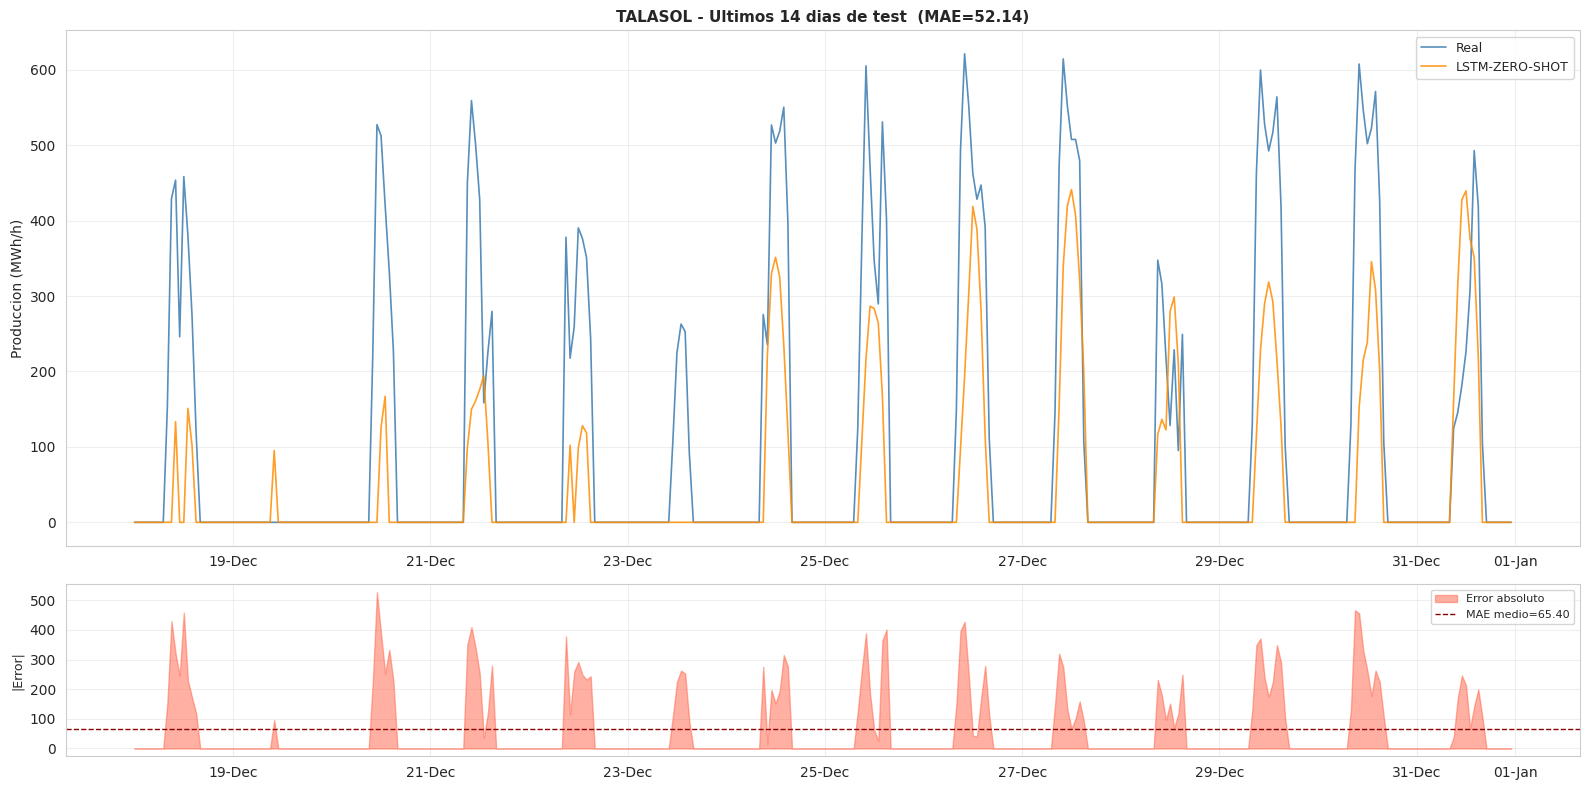

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_timeseries.png


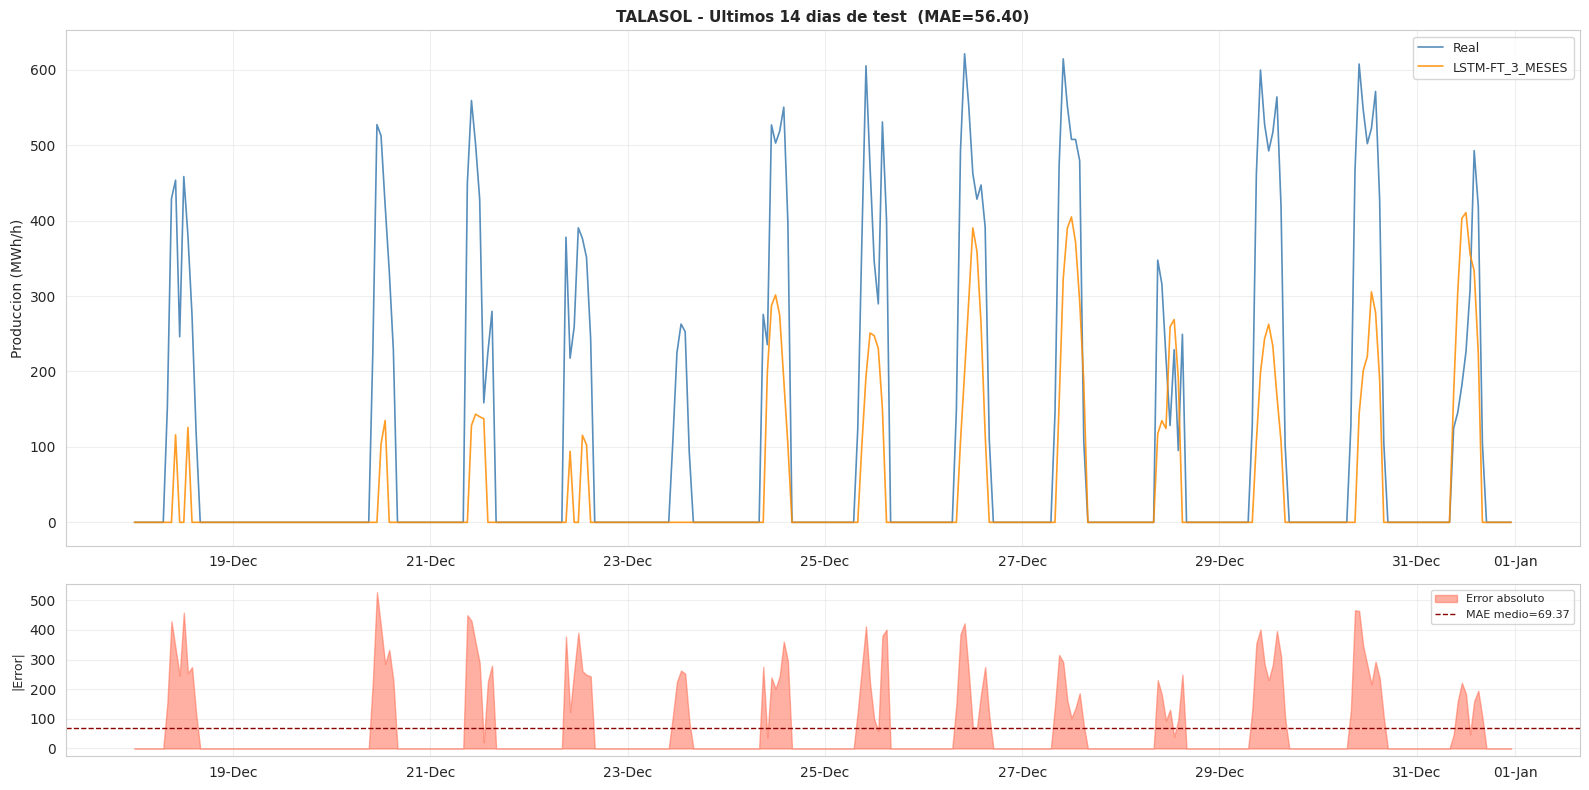

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_timeseries.png


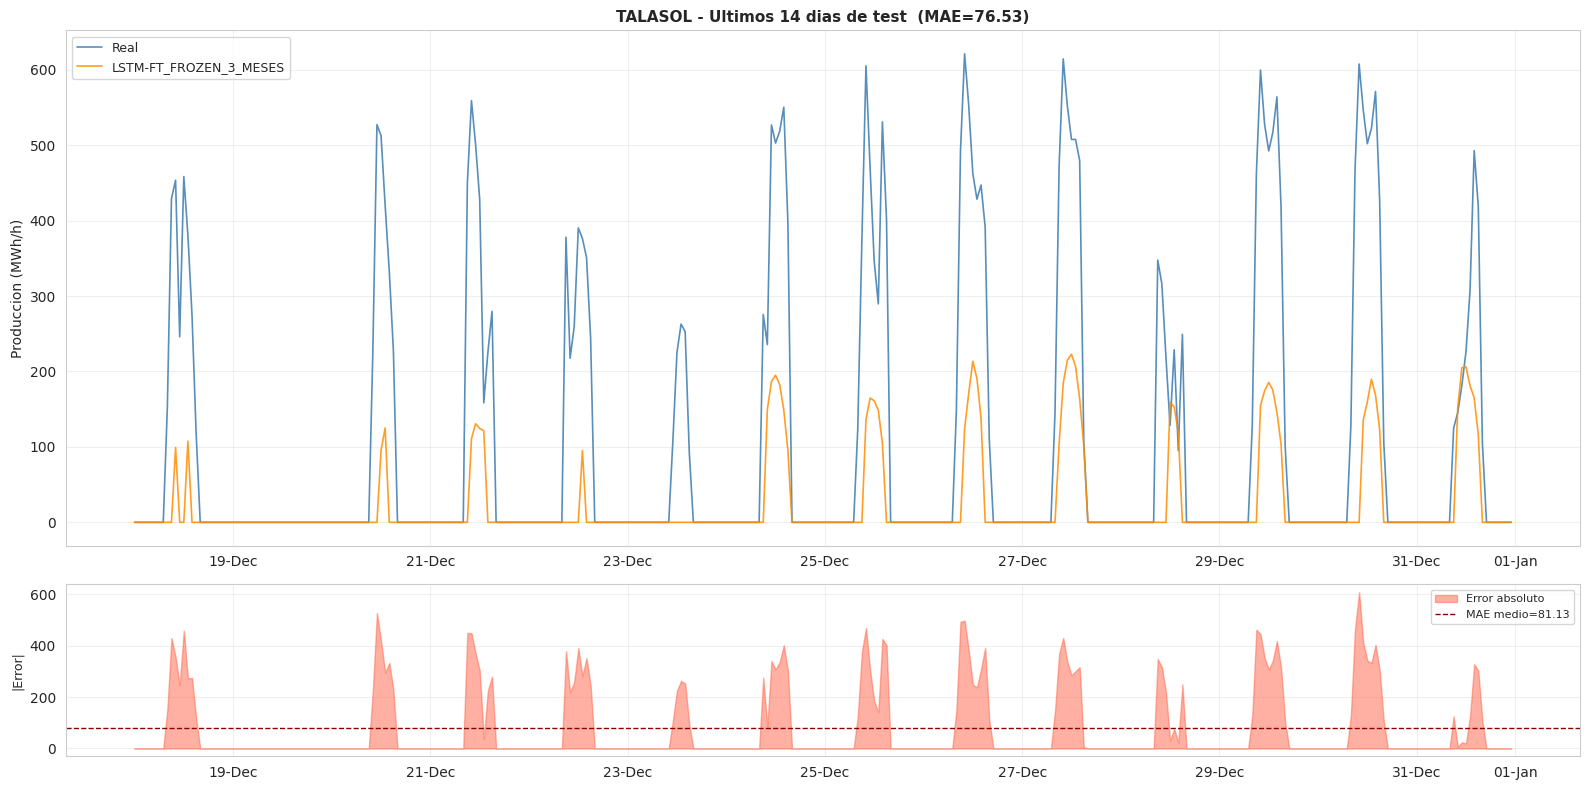

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_timeseries.png


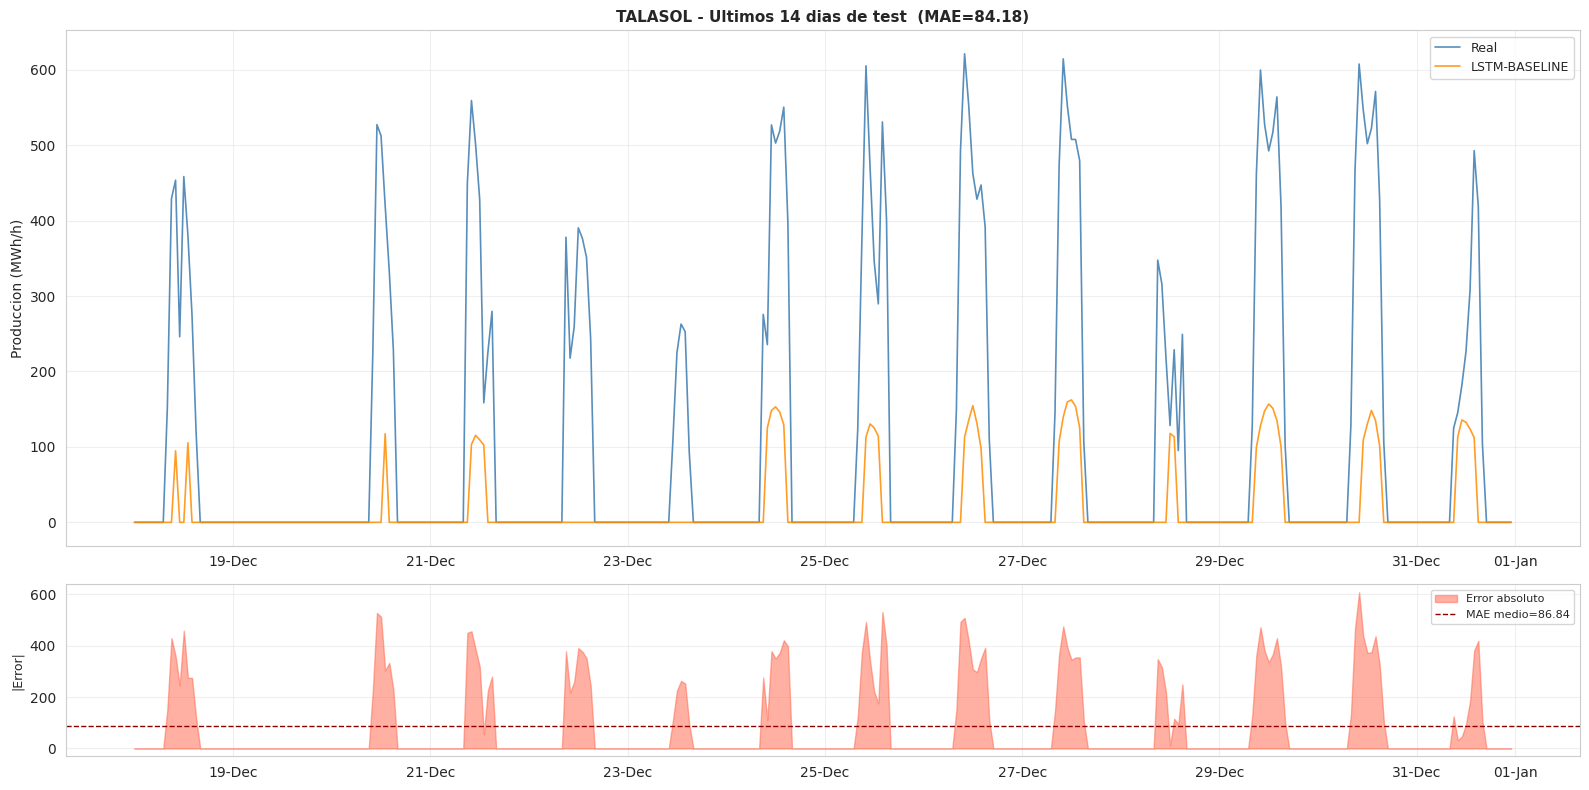

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures/TALASOL_learning_curves.png


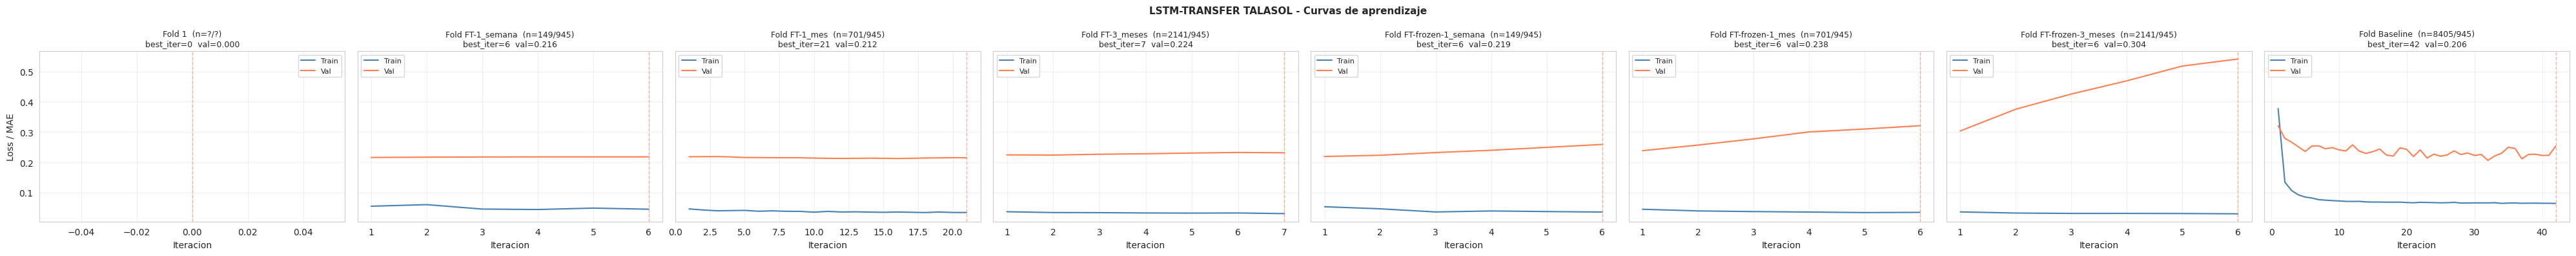


EXPERIMENTO 2 LSTM COMPLETADO
  Resultados:  /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/lstm/figures
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex2_transfer/lstm


In [12]:
# ============================================================================
# 7. VISUALIZACIÓN
# ============================================================================

print('[7/7] Visualización...')
fig_dir = RESULTS_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# ── 7a. Bar plot MAE por escenario ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

scenario_labels = df_latest['scenario'].tolist()
mae_vals        = df_latest['MAE'].tolist()

color_map = {
    'zero_shot':          '#9C27B0',
    'ft_1_semana':        '#1565C0',
    'ft_frozen_1_semana': '#64B5F6',
    'ft_1_mes':           '#1976D2',
    'ft_frozen_1_mes':    '#90CAF9',
    'ft_3_meses':         '#1E88E5',
    'ft_frozen_3_meses':  '#BBDEFB',
    'baseline':           '#2E7D32',
}
colors = [color_map.get(s, '#BDBDBD') for s in scenario_labels]

bars = ax.bar(scenario_labels, mae_vals, color=colors, alpha=0.88,
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('MAE (MW)', fontsize=10)
ax.set_title(f'MAE por escenario — LSTM Transfer Learning ({PLANTA_TARGET})',
             fontsize=11, fontweight='bold')
ax.set_xticklabels(scenario_labels, rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)

legend_elements = [
    mpatches.Patch(facecolor='#9C27B0', label='Zero-shot'),
    mpatches.Patch(facecolor='#1976D2', label='Fine-tuning (FT)'),
    mpatches.Patch(facecolor='#90CAF9', label='Fine-tuning + encoder freeze'),
    mpatches.Patch(facecolor='#2E7D32', label='Baseline (desde cero)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / 'mae_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: mae_by_scenario.png')

# ── 7b. Series temporales ─────────────────────────────────────────────────────
plot_timeseries(df_pred_zs, PLANTA_TARGET, 'lstm-zero-shot',
                save_dir=fig_dir, days=14)

if ft_preds:
    best_ft = max(ft_preds.keys(), key=lambda k: ft_scenarios[k])
    plot_timeseries(ft_preds[best_ft], PLANTA_TARGET, f'lstm-ft_{best_ft}',
                    save_dir=fig_dir, days=14)

if ft_frozen_preds:
    best_frz = max(ft_frozen_preds.keys(), key=lambda k: ft_scenarios[k])
    plot_timeseries(ft_frozen_preds[best_frz], PLANTA_TARGET,
                    f'lstm-ft_frozen_{best_frz}', save_dir=fig_dir, days=14)

plot_timeseries(df_pred_bl, PLANTA_TARGET, 'lstm-baseline',
                save_dir=fig_dir, days=14)

# ── 7c. Curvas de entrenamiento ───────────────────────────────────────────────
all_histories = [pretrain_hist]
for name, hist in ft_histories.items():
    all_histories.append({**hist, 'fold': f'FT-{name}'})
for name, hist in ft_frozen_histories.items():
    all_histories.append({**hist, 'fold': f'FT-frozen-{name}'})
all_histories.append({**baseline_hist, 'fold': 'Baseline'})

plot_learning_curves(
    all_histories, PLANTA_TARGET, 'lstm-transfer',
    save_dir=fig_dir
)

print('\n' + '=' * 80)
print('EXPERIMENTO 2 LSTM COMPLETADO')
print(f'  Resultados:  {RESULTS_DIR}')
print(f'  Figuras:     {fig_dir}')
print(f'  Checkpoints: {CHECKPOINTS_DIR}')
print('=' * 80)